# spotWithAnnularGrating — legacy combined analysis

> **This combined notebook has been split into two maintained workflows:**
> [`analyzeCenterGrating.ipynb`](analyzeCenterGrating.ipynb) and
> [`analyzeSurroundGrating.ipynb`](analyzeSurroundGrating.ipynb). Use those notebooks
> for block-level fixed-NDF + protected FilterWheel calibration, series-resistance QC,
> site-specific saving, and population analysis. The cells below are retained as a
> historical mixed-site analysis and model reference.

Python version of `spotAnnularGratingMain.m` + `analyzeSpotAnnularGrating.m` +
`populationSpotAnnularGrating.m` (linCone repo). The MATLAB loaded epochs through `riekesuite`
and split them with an interactive epoch-tree GUI; here the database *is* the tree, so grouping
is a `groupby` and no GUI is needed.

**The stimulus.** A square-wave grating masked to an annulus
(`annulusInnerDiameter/2 ≤ r ≤ annulusOuterDiameter/2`), bright bars fixed at
`brightBarContrast`, dark bars swept over `darkBarContrast`, and a disc of `spotIntensity` and
diameter `apertureDiameter` on top. Bar width and grating polarity (±1) are interleaved and
**pooled**, so each recording group gives one response-vs-darkBarContrast tuning curve.

**Two independent knobs, and it is easy to conflate them.** `annulusInnerDiameter` sets where the
*grating* is; `apertureDiameter` sets whether a *center spot* is painted over it. They are
separate objects, and all three combinations occur:

| `annulus_inner` | `apertureDiameter` | what the frame looks like | `grating_site` | `center_spot` | blocks |
|---|---|---|---|---|---|
| 0 | 0 | grating disc filling the center | `center` | `none` | 115 |
| > 0 | 0 | grating annulus, **center left empty** | `surround` | `none` | 44 |
| > 0 | > 0 | grating annulus, spot in the center | `surround` | `spot` | 21 |

The middle row is the one that breaks the intuition "no spot means the grating is in the center."
At `inner = 400`, `outer = 1200` the grating covers r = 200–600 µm and the center r = 0–200 µm is
plain background — stimulated by nothing at all. Those 44 blocks are surround recordings with an
empty center, and 37 of them are the ON-parasol surround series. So `grating_site` is keyed on
`annulusInnerDiameter`, and `center_spot` carries the aperture separately.

**The question.** As the dark bars deepen they cancel the bright bars, and the response returns
to baseline. Where that happens is the *balancing contrast*. Under a Weber/Naka-Rushton cone
model `R(I) = I/(I+I0)` the balancing contrast depends on mean light level, so measuring it
across light levels tests the cone model directly.

**Light level** comes from the rig's measured ceiling (§1): `RIG_MAX_RSTAR[rig] / 10**NDF ×
backgroundIntensity`, using the filter-wheel NDF Symphony writes into the h5. Recordings on a rig
with no filter wheel have no light level and are excluded (and reported).

In [12]:
# Pick up edits to the retinanalysis package without restarting the kernel --
# without this, a kernel that has been alive across a package change keeps
# running the old code and section 2 fails on arguments that now exist.
%load_ext autoreload
%autoreload 2

import retinanalysis as ra
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from retinanalysis.SCutils import explore as sc
from retinanalysis.SCutils.protocols import spot_annular_grating as sag

# ---- analysis settings -------------------------------------------------
# Which cell types to analyze. Type whatever you want here; the rest of the
# notebook follows.
CELL_TYPES = ('ON-parasol', 'OFF-parasol')

# Filter-wheel settings that count as analyzable. A block with no
# background:FilterWheel:NDF reading, or one outside this list, is dropped.
FILTER_WHEEL = (0.0, 0.5, 1.0)

# Bright-bar contrasts to analyze. The protocol was effectively always run at
# 0.9 or 1.0; the handful of blocks at 0.25 and 0.5 are a one-cell sweep
# (2026-04-04_E Cell1) too small to stand on its own. They are dropped rather
# than pooled, because the cone prediction is a function of the (light level,
# bright bar) pair -- mixing bright bars in one tuning curve makes the measured
# crossing uncomparable to it. Set to None to keep every contrast.
BRIGHT_CONTRAST = (0.9, 1.0)

# Minimum bar width, in microns. Below roughly this scale the optics low-pass
# the grating before it reaches the photoreceptors, so a cancellation measured
# there is partly an optical result rather than a cone one. Drops the 40 and
# 50 um blocks (9 of 180). Set to None to keep every width.
MIN_BAR_WIDTH = 40.0

# Fewest epochs a recording group may rest on. The tuning curve splits its
# epochs across ~11 dark contrasts and pools the two grating polarities within
# each, so a 10-epoch group is about one epoch per contrast with no polarity
# averaging at all -- its crossing is a single trial, not a measurement. This
# is a test on the pooled group, so a cell run twice can still qualify.
MIN_EPOCHS = 15

# Access-resistance cutoff for whole-cell epochs, in ohms. Above this the
# series resistance filters and attenuates the recorded current enough that
# the epoch is not worth keeping, so section 1b drops it.
MAX_SERIES_RESISTANCE = 30e6

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Find every block that ran the protocol

One row per epoch block with the grouping keys the MATLAB epoch tree split on — cell type, cell
label, recording mode, filter-wheel NDF, `backgroundIntensity` — plus the stimulus geometry and
the derived `grating_site` and `light_level`.

`filter_wheel_ndf` is Symphony's `background:FilterWheel:NDF`, which the parser lifts out of
`backgrounds/<device>/dataConfigurationSpans/span_0/FilterWheel` into the epoch parameters.
`sag.read_filter_wheel_ndf()` reads it straight from the h5; passing `verify_fw=True` below
cross-checks every block against the file (they agreed on every block sampled).

### Light level, from the rig calibration

Each block's mean photoisomerization rate comes from the rig's measured ceiling:

$$R^* = \frac{\mathrm{RIG\_MAX\_RSTAR}[\text{rig}]}{10^{\mathrm{NDF}}} \times \text{backgroundIntensity}$$

with `RIG_MAX_RSTAR = {'E': 30000, 'G': 77000}` — the R* at display intensity 1.0 with the wheel
at 0. The wheel is a neutral density, so it attenuates by $10^{\mathrm{NDF}}$, and the display is
linear in intensity, so the background scales it.

**The rig is not optional.** E and G differ by 2.6×, so the same wheel setting and background
mean two different light levels depending on which rig ran it. `light_level_rstar` therefore
takes the rig, and `find_blocks` passes it.

This replaces `RSTAR_TABLE`, the five-entry lookup ported from `lightLevelRStar.m`, which is kept
only as a fallback for an unrecognised rig. That table is really rig G's numbers (every entry
within 0.91–1.16× of the formula), it keyed on wheel and background alone, and it covered just
24 of 180 blocks — leaving every rig-E recording, and the whole `bg 0.5` series, with no light
level at all. That is why the Weber comparison below used to be nearly empty.

In [2]:
df_blocks = sag.find_blocks()

  2026-01-02_E_2: cannot open the h5 — no fixed-filter reading for 2 block(s)
180 blocks | 25 experiments | 59 cells


exp_name,cell_label,cell_type_short,onlineAnalysis,grating_site,center_spot,filter_wheel_ndf,stage_ndfs,backgroundIntensity,light_level,apertureDiameter,annulusInnerDiameter,annulusOuterDiameter,brightBarContrast,bar_width,n_epochs,block_id
2025-10-15_E,Cell6,ON-parasol,exc,surround,spot,0.0,,0.3,10000R*,250.0,350.0,1200.0,1.0,100.0,33,18847
2025-10-15_E,Cell6,ON-parasol,exc,surround,spot,0.0,,0.3,10000R*,250.0,350.0,1200.0,1.0,100.0,33,18848
2025-10-15_E,Cell6,ON-parasol,exc,surround,spot,0.0,,0.3,10000R*,250.0,350.0,1200.0,1.0,100.0,33,18849
2025-10-15_E,Cell6,ON-parasol,exc,surround,spot,0.0,,0.3,10000R*,250.0,350.0,1200.0,1.0,100.0,110,18850
2025-10-15_E,Cell7,ON-parasol,exc,surround,spot,0.0,,0.3,10000R*,350.0,450.0,1200.0,1.0,100.0,33,18816
2025-10-15_E,Cell7,ON-parasol,exc,surround,spot,0.0,,0.3,10000R*,350.0,450.0,1200.0,1.0,100.0,33,18817
2025-10-15_E,Cell8,ON-parasol,exc,surround,spot,0.0,,0.3,10000R*,350.0,450.0,1200.0,1.0,100.0,33,18842
2025-10-15_E,Cell8,ON-parasol,exc,surround,spot,0.0,,0.3,10000R*,350.0,450.0,1200.0,1.0,100.0,39,18843
2025-10-22_E,Cell1,ON-parasol,exc,surround,spot,0.0,EL3,0.3,10000R*,300.0,400.0,1200.0,1.0,100.0,33,18856
2025-10-22_E,Cell1,ON-parasol,exc,surround,spot,0.0,EL3,0.3,10000R*,300.0,400.0,1200.0,1.0,100.0,33,18857


### 1b. Is each block the kind of recording it says it is?

`onlineAnalysis` is a menu item the experimenter picks before a block runs, and it gets picked
wrong. A block labelled `extracellular` but actually recorded whole-cell would go through spike
detection and produce a tuning curve out of voltage-clamp current; one labelled `exc` but
recorded cell-attached would have its spikes averaged as if they were pA. Neither fails loudly.

The amplifier settles it. Symphony writes `stimulus:Amp1:seriesResistance` into every epoch, and
it is **exactly 0 for a cell-attached recording** (there is no access resistance to report) and
positive for whole-cell. Where it disagrees with the label the reading wins, and the block is
**relabelled and analyzed correctly**, not thrown away — a mislabelled cell-attached recording
gets spike sorted, a mislabelled whole-cell one gets treated as current.

The same rule runs inside `analyze_group`, so a block analyzed directly is corrected too, not
only one that came through this table. The record carries `online_analysis_recorded` alongside
the mode it was actually analyzed as.

The two directions are not symmetric:

- **`Rs > 0` against an `extracellular` label** is unambiguous — a cell-attached patch has no
  access resistance, so the cell was held whole-cell. The reading does not carry the holding
  potential, so the polarity comes from the sign of the current: inward is `exc`, outward `inh`.
  (Same inference `linear_equivalent_disc` already makes.)
- **`Rs == 0` against an `exc`/`inh` label** is *not* unambiguous. It means either cell-attached
  **or that the experimenter never filled the field in**, and both occur here — on 2025-10-22_E,
  for different cells on the same day. So the relabel is confirmed against the data first, and
  applied only to a trace that really does contain spikes. A trace with none keeps its whole-cell
  label and the printout says why.

Separately, epochs recorded through more than `MAX_SERIES_RESISTANCE` (20 MΩ) are thrown out —
per epoch inside `analyze_group`, so a block that only went bad partway keeps its good half, and
whole blocks here when nothing would be left.

On this dataset that relabels 19 blocks from `exc` to `extracellular`, leaves 10 whole-cell
blocks alone, and drops 2 (2026-04-14_E Cell3, recorded at 24.9 MΩ). Resolving a contradiction
needs the raw trace, so the cell takes about a minute.

In [3]:
df_blocks = sag.check_series_resistance(df_blocks,
              max_series_resistance=MAX_SERIES_RESISTANCE)

  2026-01-02_E_2: cannot open the h5 (FileNotFoundError) — 2 block(s) have no series-resistance reading
reading the trace for 33 block(s) whose mode the label does not settle (0 never labelled, 33 contradicted)
If this is for an LED stimulus, be sure to set b_LED=True!

Error occurred while getting actual onset/offset times: unsupported operand type(s) for *: 'float' and 'NoneType'
It could be that frame_times_ms do not have the correct number of frames due to some error in frame detection.
Check the frame monitor sample rate! On MEA Rigs, prefer 1k, errors likely with 10k.
If this is for an LED stimulus, be sure to set b_LED=True!

Error occurred while getting actual onset/offset times: unsupported operand type(s) for *: 'float' and 'NoneType'
It could be that frame_times_ms do not have the correct number of frames due to some error in frame detection.
Check the frame monitor sample rate! On MEA Rigs, prefer 1k, errors likely with 10k.
If this is for an LED stimulus, be sure to set b_

### 1c. Sanity check: are the two grating polarities pooled?

`currentGratingPolarity` (±1) flips which stripes are bright and which are dark. Pooling the two
is what removes the dependence on where the bars happen to land on the receptive field — with
only one polarity, a cell whose center sits under a bright bar and one whose center sits under a
dark bar give different answers for the same stimulus.

**They are pooled by construction.** `analyze_group` builds the tuning curve by grouping epochs on
`currentDarkContrast` alone:

```python
contrasts = np.unique(dark[valid])
resp_mean = [np.nanmean(resp_stim[valid & (dark == c)]) for c in contrasts]
```

Polarity is never a grouping variable, so both signs land in the same average — as do both bar
widths, for the same reason. The cell below verifies that against the epochs themselves rather
than by reading the code, and checks the part that is *not* guaranteed: that the pooling is
**even**. A block stopped mid-interleave leaves one polarity with an extra epoch, which tilts the
pooled mean toward it.

It walks every epoch in the dataset, so it takes a minute or two. Nothing downstream depends on
it — it is a check, not a filter.

In [4]:
# Walks every epoch -- a minute or two. Set to False to skip on a re-run.
CHECK_POLARITY = True

if CHECK_POLARITY:
    polarity = sag.check_polarity_pooling(df_blocks)
    display(polarity[~polarity['balanced']]
            .assign(imbalance=lambda d: d['n_pos'] - d['n_neg'])
            .groupby('imbalance').size().reset_index(name='cells'))

polarity is pooled by construction: analyze_group groups on currentDarkContrast only.
  7343 epochs over 180 blocks; 120 blocks record currentGratingPolarity (5306 epochs), 60 do not (2037 epochs)
  values recorded: [np.float64(-1.0), np.float64(1.0)]
  (block x contrast x bar width) cells: 1075 — 849 balanced (79%), 226 off by 1 epoch or less
    block 34020 dark -1 bar 75: +1 x1, -1 x0
    block 34020 dark -0.9 bar 75: +1 x1, -1 x0
    block 34020 dark -0.8 bar 75: +1 x1, -1 x0
    block 34020 dark -0.7 bar 75: +1 x1, -1 x0
    block 35064 dark -0.9 bar 100: +1 x1, -1 x0
  overall epoch counts: {1.0: 2766, -1.0: 2540}


,imbalance,cells
0,1,226


## 2. Group into recordings, then keep the cell types you asked for

A group is the epoch-tree leaf: experiment × rig × cell × recording mode × grating site ×
filter wheel × background. `group_blocks` drops blocks with no filter-wheel reading, any whose
wheel is outside `FILTER_WHEEL`, any whose bright bar is outside `BRIGHT_CONTRAST`, and any
run below `MIN_BAR_WIDTH`, reporting all four. It then drops whole recording groups left with
fewer than `MIN_EPOCHS` epochs. `select_cell_types` then keeps `CELL_TYPES`.

Unlike the old selected filter this does not pin the grating site to the cell type, so
`grating_site` stays a condition you can group on — and the table carries the grating geometry
(aperture, annulus inner and outer diameter, spot intensity) so you can see what was actually
shown, plus the series resistance section 1b read.

**The table is ordered by cell, not by epoch count.** Every recording of one cell on one date sits
on consecutive rows under a single `<experiment>/<cell>` heading, because those rows are the same
cell under different conditions and reading them against each other is the point — a cell run at
three light levels is three rows that only mean something side by side. Within a cell the rows
still run most epochs first, and cells and experiments are ranked by their totals, so the
best-sampled cell is still near the top; it just no longer has its conditions strewn down the
table between other cells'. The `cell` id in the first column is the one `describe_cell`,
`inspect_cell` and the `CELL` setting at the bottom of the notebook take.

**`rstar_level` is the light level as a rung.** The calibration in section 1 gives a continuous
R* — 11550 on rig G at wheel 0 / bg 0.15, 9000 on rig E at wheel 0 / bg 0.30 — and those exact
numbers stay in `rstar`. For grouping and labelling each recording is snapped to the nearest of

```
sag.RSTAR_LEVELS = 1000, 2000, 4000, 5000, 7000, 10000, 15000, 20000  R*
```

so 11550 and 12000 R* land on the same rung instead of splitting a column of one. Nearest is
measured in **log** space, because a light level only means anything as a ratio: 1500 R* (rig E,
wheel 1, bg 0.5) is 1.5× the 1000 rung and 0.75× the 2000 one, so it rounds up, where a linear
tie-break would have called it either. Every plot that needs a real intensity — the Weber
comparison in section 6 — still reads `rstar`, never the rung.

**`bright` is the other half of the cone prediction.** The dark bar has to cancel *this* bright
bar, so the predicted balancing contrast is a function of the pair (light level, bright contrast),
not of light level alone — `cone_predict_dark_contrast(rstar, bright_contrast)` takes both, and
`analyze_group` already reads the realized `currentBrightContrast` per epoch.

`BRIGHT_CONTRAST = (0.9, 1.0)` restricts the analysis to the two the protocol was effectively
always run at. That drops three blocks from 2026-04-04_E Cell1, which was swept over 0.9 / 0.5 /
0.25 at two wheel settings. Dropping them is what makes the rest well-defined: bright contrast is
a block-level setting but *not* a grouping key, so before the filter that one cell's sweep pooled
into a single group whose tuning curve averaged three different stimuli. With the filter no group
mixes bright bars — `group_blocks` still lists every distinct value in `bright` and warns by name
if one ever does.

What survives is nearly confounded with light level: 1.0 is almost entirely rig E at 10000 R*,
and the one place both contrasts occur at a single light level is rig E at 15000 R*, 18
recordings against 3. So this dataset cannot separate a bright-contrast effect from a light-level
one — which is fine, because the prediction takes the recording's own bright contrast anyway.

`stage_ndfs`, the stack of fixed neutral-density filters in the light path, is still on `groups`
if you need to check what the wheel setting does not cover, but it is out of the table here: the
R* above comes from the rig's measured ceiling and the wheel alone.

**`bar_width` is a per-block setting here, not an interleaved one.** The protocol supports
interleaving bar width and `analyze_group` pools across it exactly as it pools polarity, but every
one of the 180 blocks in this dataset ran a single width — so the `MIN_BAR_WIDTH` cutoff is a
clean per-block test rather than an epoch-level one. Below roughly 60 µm the optics low-pass the
grating before it reaches the photoreceptors, so a cancellation measured there is partly an
optical result; the cutoff drops the 40 µm (2 blocks) and 50 µm (7 blocks) recordings. What
survives is 75, 100, 150 and 200 µm.

**`MIN_EPOCHS` is a test on the group, not the block.** The other filters throw out blocks; this
one runs after the blocks are pooled, because a cell run twice at the same condition can reach a
usable count between them and dropping its blocks singly would lose a group that is actually well
sampled. The tuning curve divides a group's epochs across ~11 dark contrasts and pools the two
polarities within each, so a 10-epoch group is roughly one epoch per contrast with no polarity
averaging left — its crossing is a single trial. Cutting at 16 removes 8 groups holding 85 epochs
(1.7% of the total) and costs two cells entirely, 2026-01-02_E Cell6 and 2026-04-04_E Cell1.

`selected` is the menu for everything after this: section 4 analyzes one row of it, section 5
runs all of them.

In [5]:
groups = sag.group_blocks(df_blocks, allowed_filter_wheel=FILTER_WHEEL,
                          allowed_bright_contrast=BRIGHT_CONTRAST,
                          min_bar_width=MIN_BAR_WIDTH, min_epochs=MIN_EPOCHS)
selected = sag.select_cell_types(groups, cell_types=CELL_TYPES)

# One cell's recordings on adjacent rows. Sorting on epochs alone scattered a
# cell down the table -- 2026-06-04_G/Cell4 has ten conditions, which landed all
# over it -- so rank instead: experiments by their total epochs, cells within an
# experiment the same way, and a cell's own recordings by epochs. The
# best-sampled cell is still near the top, but it arrives as a block, so the
# conditions one cell was run in can be read off in one place.
# The index shown is what section 4 selects with PICK.
selected = (selected
            .assign(_exp=selected.groupby('exp_name')['epochs'].transform('sum'),
                    _cell=selected.groupby(['exp_name', 'cell_label'])['epochs']
                                  .transform('sum'))
            .sort_values(['_exp', 'exp_name', '_cell', 'cell_label', 'epochs'],
                         ascending=[False, True, False, True, False])
            .drop(columns=['_exp', '_cell'])
            .reset_index(drop=True))

# Displayed as a tree keyed on the cell: the id repeats only on the row that
# starts a new cell, with a rule above it. `cell` is the '<experiment>/<cell>'
# id describe_cell(), inspect_cell() and the CELL setting at the bottom take,
# so a row here can be pasted straight into them.
disp = selected.reset_index()
disp['cell'] = disp['exp_name'] + '/' + disp['cell_label']
cols = ['index', 'cell', 'rig', 'cell_type_short', 'onlineAnalysis',
        'grating_site', 'center_spot', 'aperture', 'annulus_inner', 'annulus_outer',
        'spot_intensity', 'bright', 'bar_width', 'filter_wheel_ndf', 'backgroundIntensity',
        'rstar', 'rstar_level', 'blocks', 'epochs']
cols += [c for c in ('rs_mohm',) if c in disp.columns]
sc.tree_table(disp[cols].round({'rstar': 0}),
    levels=['cell', 'rig', 'cell_type_short'],
    height=340, num_cols=('index', 'aperture', 'annulus_inner', 'annulus_outer',
                          'spot_intensity', 'filter_wheel_ndf', 'backgroundIntensity',
                          'rstar', 'rstar_level', 'blocks', 'epochs', 'rs_mohm'))

# The two geometry knobs are independent: grating_site is where the grating is
# (annulus inner diameter), center_spot is whether a spot was painted over the
# middle (aperture diameter). "surround / none" is an annulus with nothing in
# the center at all -- not a center recording.
print('\nstimulus configuration (recordings)')
display(pd.crosstab([selected['cell_type_short'], selected['grating_site']],
                    selected['center_spot']))

print('\nbar width kept, by cell type (µm)')
display(pd.crosstab(selected['cell_type_short'], selected['bar_width']))

# What the cone prediction actually needs: the (light level, bright bar) pair.
# 1.0 is almost entirely rig E at 10000 R*, so the two are nearly confounded.
print('\nbright bar contrast x light level (recordings)')
display(pd.crosstab([selected['rig'], selected['rstar_level']], selected['bright']))

dropping 21 block(s) with no filter-wheel NDF: 2026-05-08_E
dropping 6 block(s) whose filter wheel is not in [0.0, 0.5, 1.0]: NDF [2.0, 3.0, 4.0]
dropping 3 block(s) whose bright bar contrast is not in [0.9, 1.0]: 0.25 (1 block), 0.5 (2 blocks) -- 2026-04-04_E
dropping 7 recording group(s) with fewer than 15 epochs (70 epochs, 10-10 each):
    2026-04-03_E_2 Cell5 horizontal extracellular center 15000R*: 10 epochs
    2026-04-04_E Cell1 OFF-parasol extracellular center 15000R*: 10 epochs
    2026-04-04_E Cell1 OFF-parasol extracellular center 2000R*: 10 epochs
    2026-04-04_E Cell2 ON-parasol extracellular center 5000R*: 10 epochs
    2026-04-04_E Cell3 ON-parasol extracellular center 15000R*: 10 epochs
    2026-04-04_E Cell3 ON-parasol extracellular center 5000R*: 10 epochs
    2026-04-04_E Cell4 ON-parasol extracellular center 15000R*: 10 epochs
88 recording groups (experiment x cell x mode x grating site x filter wheel x background)


/Users/chrischen/Documents/GitHub/retinanalysis/src/retinanalysis/SCutils/protocols/spot_annular_grating.py:810: RuntimeWarning: All-NaN slice encountered
  agg['rs_mohm'] = ('series_resistance', lambda s: np.round(np.nanmedian(s) / 1e6, 2))


cell_type_short,rig,exp_name,cell_label,onlineAnalysis,grating_site,center_spot,aperture,annulus_inner,annulus_outer,spot_intensity,bright,bar_width,filter_wheel_ndf,backgroundIntensity,rstar_level,blocks,epochs,rs_mohm,epochs_high_rs
OFF-parasol,E,2025-10-22_E,Cell3,extracellular,surround,spot,350.0,450.0,1200.0,0.15,1,100,0.0,0.3,10000.0,3,99,0.0,0
,,2025-11-06_E,Cell4,extracellular,surround,spot,250.0,350.0,1200.0,0.25,1,100,0.0,0.3,10000.0,3,99,0.0,0
,,2026-01-02_E,Cell6,exc,surround,spot,300.0,400.0,1200.0,0.225,1,100,0.0,0.3,10000.0,1,15,14.38,0
,,2026-02-26_E,Cell1,extracellular,center,none,0.0,0.0,300.0,0.0,0.9,50,0.0,0.5,15000.0,2,47,0.0,0
,,,Cell5,extracellular,center,none,0.0,0.0,300.0,0.0,0.9,"50, 75",0.0,0.5,15000.0,3,83,0.0,0
,,2026-04-03_E,Cell4,extracellular,center,none,0.0,0.0,200.0,0.0,0.9,75,0.0,0.5,15000.0,1,33,0.0,0
,,2026-04-14_E,Cell1,extracellular,surround,spot,200.0,300.0,1200.0,0.4,0.9,75,0.0,0.5,15000.0,1,55,0.0,0
,,,,extracellular,center,none,0.0,0.0,300.0,0.0,0.9,75,0.0,0.5,15000.0,2,77,0.0,0
,,,,extracellular,center,none,0.0,0.0,300.0,0.0,0.9,75,1.0,0.5,2000.0,2,88,0.0,0
,,,Cell3,extracellular,center,none,0.0,0.0,400.0,0.0,0.9,75,0.0,0.5,15000.0,2,88,0.0,0


71 of 88 groups are ON-parasol, OFF-parasol
rig                            E                 G              
onlineAnalysis               exc extracellular exc extracellular
cell_type_short grating_site                                    
OFF-parasol     center         2            15   8            16
                surround       1             3   0             0
ON-parasol      center         0             4   0             0
                surround       1            21   0             0


index,cell,rig,cell_type_short,onlineAnalysis,grating_site,center_spot,aperture,annulus_inner,annulus_outer,spot_intensity,bright,bar_width,filter_wheel_ndf,backgroundIntensity,rstar,rstar_level,blocks,epochs,rs_mohm
0,2026-06-04_G/Cell4,G,OFF-parasol,extracellular,center,none,0.0,0.0,300.0,0.3,0.9,100,1.0,0.3,2310.0,2000.0,2,98,0.0
1,,,,extracellular,center,none,0.0,0.0,300.0,0.15,0.9,100,0.5,0.15,3652.0,4000.0,1,66,0.0
2,,,,extracellular,center,none,0.0,0.0,300.0,0.15,0.9,100,0.0,0.15,11550.0,10000.0,1,66,0.0
3,,,,extracellular,center,none,0.0,0.0,300.0,0.15,0.9,100,1.0,0.15,1155.0,1000.0,1,66,0.0
4,,,,exc,center,none,0.0,0.0,300.0,0.15,0.9,100,0.0,0.15,11550.0,10000.0,1,66,7.89
5,,,,extracellular,center,none,0.0,0.0,300.0,0.3,0.9,100,0.5,0.3,7305.0,7000.0,1,61,0.0
6,,,,exc,center,none,0.0,0.0,300.0,0.3,0.9,100,1.0,0.3,2310.0,2000.0,1,46,7.89
7,,,,exc,center,none,0.0,0.0,300.0,0.15,0.9,100,1.0,0.15,1155.0,1000.0,1,36,7.89
8,,,,exc,center,none,0.0,0.0,300.0,0.15,0.9,100,0.5,0.15,3652.0,4000.0,1,32,7.89
9,,,,exc,center,none,0.0,0.0,300.0,0.3,0.9,100,0.0,0.3,23100.0,20000.0,1,19,7.89


...

center_spot                   none  spot
cell_type_short grating_site            
OFF-parasol     center          41     0
                surround         0     4
ON-parasol      center           4     0
                surround        16     6


bar width kept, by cell type (µm)


bar_width,100,150,200,50,"50, 75",75
cell_type_short,,,,,,
OFF-parasol,29,2,0,3,1,10
ON-parasol,18,0,4,0,0,4



bright bar contrast x light level (recordings)


bright           0.9   1
rig rstar_level         
E   2000.0        14   0
    10000.0        0  14
    15000.0       16   3
G   1000.0         5   0
    2000.0         4   0
    4000.0         6   0
    7000.0         3   0
    10000.0        5   0
    20000.0        1   0

In [8]:
print('grating site x cell type (all blocks that passed the filters)')
display(pd.crosstab(df_blocks['cell_type_short'], df_blocks['grating_site']))

print('\ngrating geometry actually used (aperture / annulus inner / outer, µm)')
display(selected.groupby(['grating_site', 'aperture', 'annulus_inner', 'annulus_outer'])
                .agg(recordings=('epochs', 'size'), epochs=('epochs', 'sum')))

print('\nlight settings kept')
display(selected.groupby(['filter_wheel_ndf', 'backgroundIntensity', 'light_setting'])
                .size().reset_index(name='recordings'))

grating site x cell type (all blocks that passed the filters)


grating_site,center,surround
cell_type_short,,
OFF-midget,8,0
OFF-parasol,64,8
ON-midget,4,3
ON-parasol,19,50
bipolar,4,4
horizontal,16,0



grating geometry actually used (aperture / annulus inner / outer, µm)


recordings  epochs
grating_site aperture annulus_inner annulus_outer                    
center       0.0      0.0           200.0                   1      33
                                    300.0                  30    1863
                                    400.0                   4     220
                                    500.0                  10     419
surround     0.0      300.0         1200.0                  2     132
                      350.0         1200.0                  2     176
                      400.0         1200.0                  9     737
                      450.0         1200.0                  3     231
             200.0    300.0         1200.0                  1      55
             250.0    350.0         1200.0                  2     308
             300.0    400.0         1200.0                  3     147
             350.0    450.0         1200.0                  4     270


light settings kept


,filter_wheel_ndf,backgroundIntensity,light_setting,recordings
0,0.0,0.15,FW0/bg0.15,5
1,0.0,0.30,FW0/bg0.3,15
2,0.0,0.50,FW0/bg0.5,19
3,0.5,0.15,FW0.5/bg0.15,6
4,0.5,0.30,FW0.5/bg0.3,3
5,1.0,0.15,FW1/bg0.15,5
6,1.0,0.30,FW1/bg0.3,4
7,1.0,0.50,FW1/bg0.5,14


### Rig E vs rig G

The rig is the letter at the end of the experiment name. Worth checking before pooling: if a cell
type or recording mode only ever ran on one rig, then any rig difference and that factor are
confounded and cannot be separated in this dataset.

In [6]:
print('recordings per rig')
display(pd.crosstab([selected['cell_type_short'], selected['grating_site']],
                    [selected['rig'], selected['onlineAnalysis']]))

print('\nepochs and cells per rig')
display(selected.groupby('rig').agg(recordings=('epochs', 'size'),
                                    cells=('cell_label', 'nunique'),
                                    experiments=('exp_name', 'nunique'),
                                    epochs=('epochs', 'sum')))

recordings per rig


rig                            E                 G              
onlineAnalysis               exc extracellular exc extracellular
cell_type_short grating_site                                    
OFF-parasol     center         2            15   8            16
                surround       1             3   0             0
ON-parasol      center         0             4   0             0
                surround       1            21   0             0


epochs and cells per rig


,recordings,cells,experiments,epochs
rig,,,,
E,47,8,16,3111
G,24,4,1,1480


## 3. Stimulus schematic

The main frame, rendered by the same recipe as the protocol's `createAnnularGrating` plus the
center spot, computed in microns. Top row: grating over the surround (ON parasols). Bottom:
grating over the center (OFF parasols).

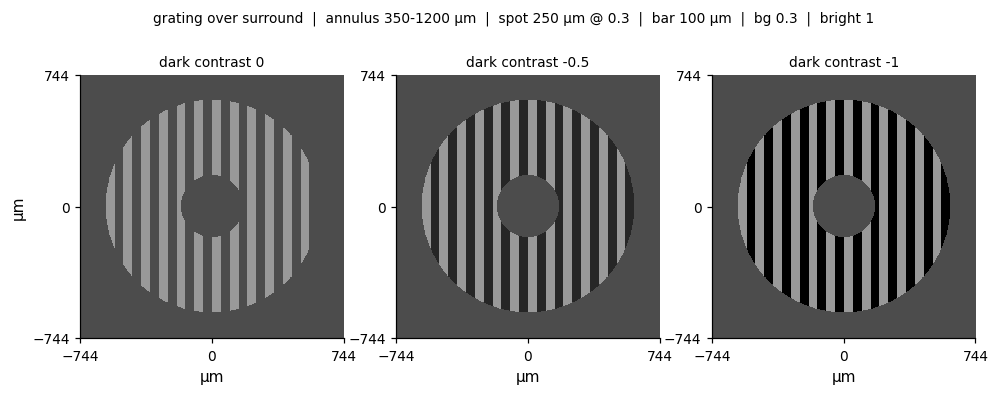

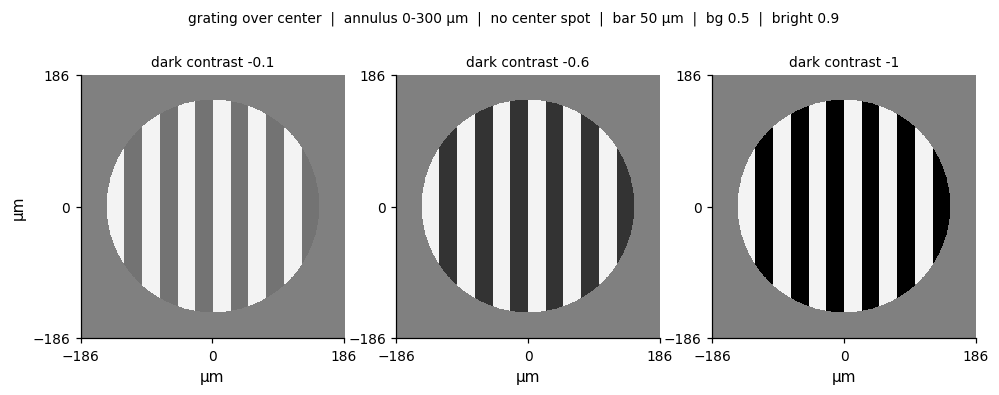

In [7]:
def block_params(block_id):
    exp = df_blocks.loc[df_blocks.block_id.eq(block_id), 'exp_name'].iloc[0]
    return ra.StimBlock(exp, int(block_id), verbose=False).df_epochs['epoch_parameters'].iloc[0]

on_block = df_blocks[df_blocks.cell_type_short.eq('ON-parasol')
                     & df_blocks.grating_site.eq('surround')].block_id.iloc[0]
off_block = df_blocks[df_blocks.cell_type_short.eq('OFF-parasol')
                      & df_blocks.grating_site.eq('center')].block_id.iloc[0]

sag.plot_stimulus_schematic(block_params(on_block))
sag.plot_stimulus_schematic(block_params(off_block));

## 4. Analyze one recording, or several of one cell

`PICK` takes a row index from the section 2 table, or a list of them — `PICK = 9` and
`PICK = [6, 7, 8, 9]` both work. Since that table is now ordered by cell, one cell's conditions
are consecutive rows, so a slice of consecutive indices *is* a cell. Before anything runs, the
cell's full condition list is printed — named, not just counted — so you can tell what you left
out of the pick.

`analyze_group` pools a row's blocks, detects spikes (extracellular) or smooths and
baseline-subtracts (whole-cell), measures the response in the stimulus window, pools across bar
width and polarity, and returns the tuning curve with its cancellation point. Spiking responses
are firing rates in Hz; whole-cell responses are mean smoothed current in pA. Any epoch above
the series-resistance cutoff is dropped here, per epoch, and reported.

**Per recording**, `keep_raw=True` makes `analyze_group` hold on to the amplifier traces it
loaded, so these views are the same data at three removes and cost one load between them:

1. **Every epoch as it came out of the h5**, one panel per block, all epochs overlaid — no
   filtering, no smoothing, no spike detection, just `amp_data`. A recording group pools several
   blocks and they fail independently, so a cell lost partway, a drifting baseline or a gain
   change between blocks shows up here before it quietly biases the pooled tuning curve. Each
   panel's title carries that block's series resistance.
2. **The same traces grouped by dark-bar contrast**, with the spike raster beside them for a
   cell-attached recording — the view that shows the response itself.
3. **The summary**: mean trace per contrast, and the tuning curve with its cancellation point.

Views 1 and 2 are two figures per recording, so `SHOW_RAW` draws them only for a single pick by
default; view 3 is always drawn, once per pick.

**Across the picks**, `plot_tuning_overlay` puts every chosen tuning curve on one pair of axes —
the comparison a multi-row pick is for. Both panels plot `response − baseline`, so each curve
crosses zero at its own balancing contrast (marked ▾), and light level is colored on the same
sequential ramp the population figures use, with the dash carrying recording mode and the marker
carrying grating site.

- **Left, recorded units.** Hz and pA share no axis, so if the picks span both recording modes
  this splits into one panel per unit rather than overlaying them.
- **Right, normalized.** Each curve is divided by its own `|response − baseline|` at its most
  negative dark contrast — the deepest dark bar it was run at, where the grating is furthest from
  cancelling and the response largest, and the one point every recording of this protocol has in
  common. Every curve is then ±1 there, which asks the only question that survives across
  conditions: *where along the contrast axis does the response return to baseline*, rather than
  how many Hz or pA it started from. The divisor is a magnitude, so it is positive and no
  crossing moves. This panel is one axes however many units are on the left, which is the point
  of normalizing.

`sag.tuning_overlay(recs)` returns the numbers behind both panels, including the amplitude each
curve was divided by; the table under the figure is that, one row per pick.


2026-06-04_G/Cell4  |  OFF-parasol  |  10 recording condition(s), 11 blocks, 556 epochs
   [0] onlineAnalysis=extracellular | light_setting=FW1/bg0.3 | filter_wheel_ndf=1.0 | backgroundIntensity=0.3  (2 blocks, 98 epochs)
   [1] onlineAnalysis=extracellular | light_setting=FW0.5/bg0.15 | filter_wheel_ndf=0.5 | backgroundIntensity=0.15  (1 blocks, 66 epochs)
   [2] onlineAnalysis=extracellular | light_setting=FW0/bg0.15 | filter_wheel_ndf=0.0 | backgroundIntensity=0.15  (1 blocks, 66 epochs)
   [3] onlineAnalysis=extracellular | light_setting=FW1/bg0.15 | filter_wheel_ndf=1.0 | backgroundIntensity=0.15  (1 blocks, 66 epochs)
   [4] onlineAnalysis=exc | light_setting=FW0/bg0.15 | filter_wheel_ndf=0.0 | backgroundIntensity=0.15  (1 blocks, 66 epochs)
   [5] onlineAnalysis=extracellular | light_setting=FW0.5/bg0.3 | filter_wheel_ndf=0.5 | backgroundIntensity=0.3  (1 blocks, 61 epochs)
   [6] onlineAnalysis=exc | light_setting=FW1/bg0.3 | filter_wheel_ndf=1.0 | backgroundIntensity=0.3  (1 b

onlineAnalysis,grating_site,aperture,annulus_inner,annulus_outer,light_setting,filter_wheel_ndf,backgroundIntensity,blocks,epochs,block_ids
extracellular,center,0.0,0.0,300.0,FW1/bg0.3,1.0,0.3,2,98,"35054, 35056"
extracellular,center,0.0,0.0,300.0,FW0.5/bg0.15,0.5,0.15,1,66,35051
extracellular,center,0.0,0.0,300.0,FW0/bg0.15,0.0,0.15,1,66,35052
extracellular,center,0.0,0.0,300.0,FW1/bg0.15,1.0,0.15,1,66,35053
exc,center,0.0,0.0,300.0,FW0/bg0.15,0.0,0.15,1,66,35065
extracellular,center,0.0,0.0,300.0,FW0.5/bg0.3,0.5,0.3,1,61,35055
exc,center,0.0,0.0,300.0,FW1/bg0.3,1.0,0.3,1,46,35063
exc,center,0.0,0.0,300.0,FW1/bg0.15,1.0,0.15,1,36,35062
exc,center,0.0,0.0,300.0,FW0.5/bg0.15,0.5,0.15,1,32,35061
exc,center,0.0,0.0,300.0,FW0/bg0.3,0.0,0.3,1,19,35064



=== [0] 2026-06-04_G Cell4 — extracellular, grating over center, FW1/bg0.3 (98 epochs) ===
If this is for an LED stimulus, be sure to set b_LED=True!

Error occurred while getting actual onset/offset times: unsupported operand type(s) for *: 'float' and 'NoneType'
It could be that frame_times_ms do not have the correct number of frames due to some error in frame detection.
Check the frame monitor sample rate! On MEA Rigs, prefer 1k, errors likely with 10k.
If this is for an LED stimulus, be sure to set b_LED=True!

Error occurred while getting actual onset/offset times: unsupported operand type(s) for *: 'float' and 'NoneType'
It could be that frame_times_ms do not have the correct number of frames due to some error in frame detection.
Check the frame monitor sample rate! On MEA Rigs, prefer 1k, errors likely with 10k.
2026-06-04_G | RGC\OFF-parasol | Cell4 | extracellular | grating center | FW=1.0 bg=0.30 (2000R*) | 98 epochs  Rs=0 (cell-attached)
  dark contrasts : [-1.  -0.9 -0.8 -

,pick,cell,online_analysis,grating_site,light_level,epochs,units,ref_contrast,ref_amplitude,crossing
0,0,2026-06-04_G/Cell4,extracellular,center,2000R*,98,rate (Hz),-1.0,40.65,-0.43
1,2,2026-06-04_G/Cell4,extracellular,center,10000R*,66,rate (Hz),-1.0,26.67,-0.40


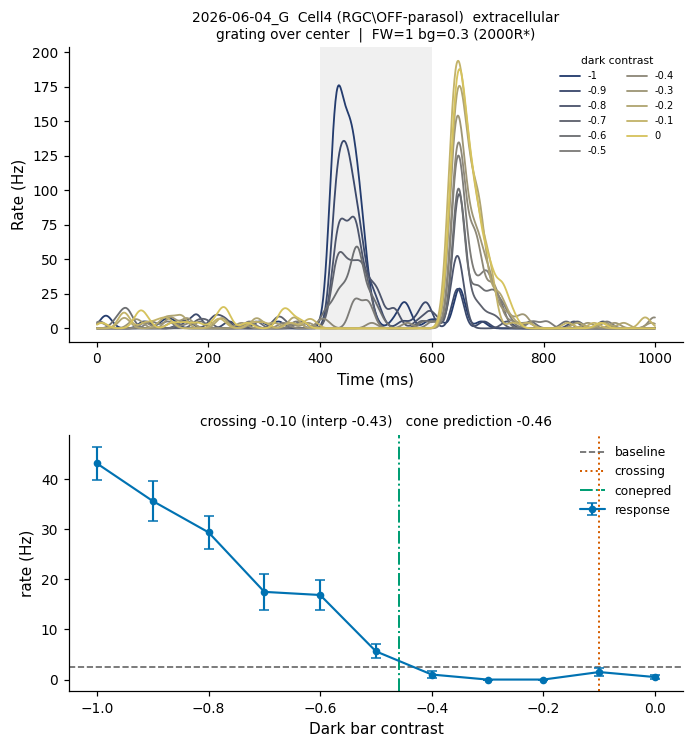

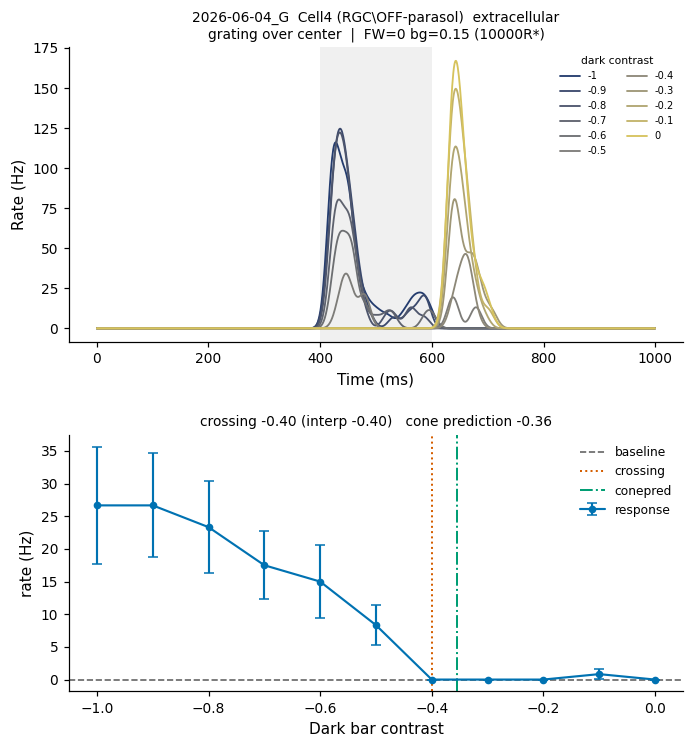

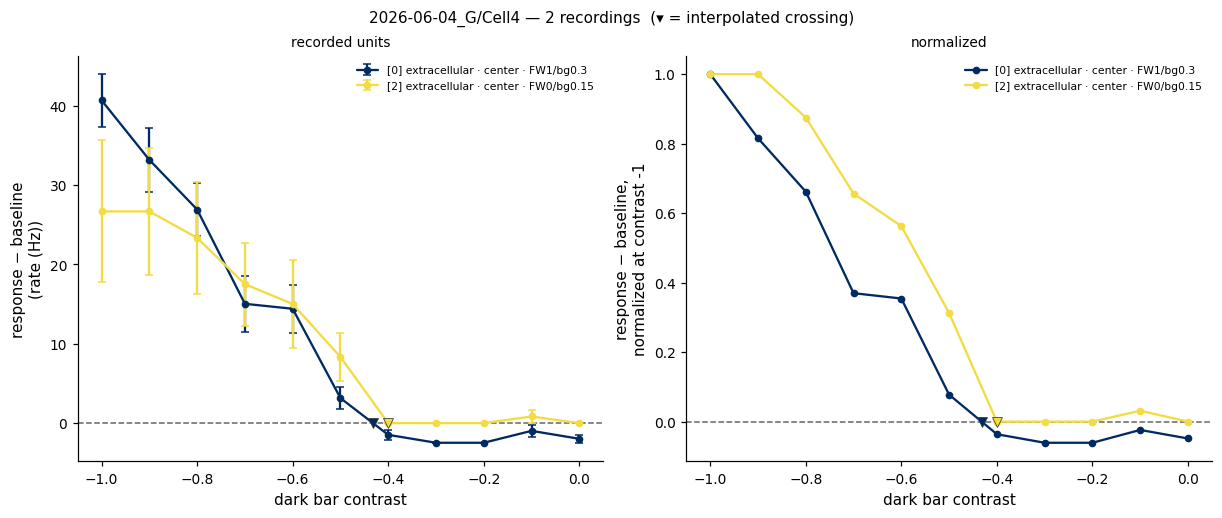

In [35]:
# One row index from the section 2 table, or several of them. Because the table
# is now ordered by cell, a cell's conditions are consecutive, so a slice picks
# a cell out of it: PICK = 9 analyzes one recording, PICK = [6, 7, 8, 9] the
# four rows of one cell and then overlays their tuning curves.
PICK = [0,2]

# The two raw views cost a figure each per recording, so by default they are
# drawn only when a single row was picked and the overlay is what several rows
# are for. Set True to see them for every pick -- they are the check for a cell
# lost partway through a block, worth doing once per recording you trust.
SHOW_RAW = None              # None -> only when one row was picked

picks = [int(PICK)] if np.isscalar(PICK) else [int(p) for p in PICK]
rows = selected.loc[picks]
show_raw = (len(picks) == 1) if SHOW_RAW is None else bool(SHOW_RAW)

# The overlay is meant to be one cell across conditions. It still draws for a
# mixed set, but then a difference between curves is a difference between cells
# as much as between conditions, so say so rather than let it pass.
cells = list(dict.fromkeys(f'{r.exp_name}/{r.cell_label}' for r in rows.itertuples()))
if len(cells) > 1:
    print(f'note: these {len(picks)} rows span {len(cells)} cells '
          f'({", ".join(cells)}) -- the overlay below compares cells, not conditions\n')

# Which conditions does each cell have? Named, so you can see what you are not
# looking at when you analyze only some of them.
for cell in cells:
    sag.describe_cell(cell, selected)

recs = []
for pick, row in rows.iterrows():
    print(f'\n=== [{pick}] {row.exp_name} {row.cell_label} — {row.onlineAnalysis}, '
          f'grating over {row.grating_site}, {row.light_setting} '
          f'({row.epochs} epochs) ===')
    rec = sag.analyze_group(row.exp_name, [int(b) for b in row.block_ids.split(',')],
                            online_analysis=row.onlineAnalysis,
                            max_series_resistance=MAX_SERIES_RESISTANCE, keep_raw=True)
    recs.append(rec)
    if show_raw:
        # 1. The traces exactly as loaded from the h5, one panel per block.
        sag.plot_raw_blocks(rec)
        # 2. The same traces grouped by contrast, with the raster for a spiking cell.
        sag.plot_raw_epochs(rec, max_contrasts=4)
    # 3. The summary those traces reduce to.
    sag.plot_group(rec)

# What picking several rows is for: their tuning curves on one pair of axes,
# in recorded units and normalized to each curve's own amplitude at its deepest
# dark bar, so the light levels can be read against each other.
if len(recs) > 1:
    labels = [f'[{p}] {r.onlineAnalysis} · {r.grating_site} · {r.light_setting}'
              for p, r in zip(picks, rows.itertuples())]
    sag.plot_tuning_overlay(recs, labels=labels)

    print('\nwhat each curve was divided by, and where it crosses baseline')
    overlay = sag.tuning_overlay(recs)
    overlay['pick'] = [picks[p] for p in overlay['position']]
    display(overlay.groupby(['pick', 'cell', 'online_analysis', 'grating_site',
                             'light_level'], sort=True)
            .agg(epochs=('n_epochs', 'first'), units=('units', 'first'),
                 ref_contrast=('ref_contrast', 'first'),
                 ref_amplitude=('ref_amplitude', 'first'),
                 crossing=('crossing_interp', 'first')).round(2).reset_index());

## 5. Batch analyze and save

Runs every row of `selected`. Records go to `<OUTPUT_DIR>/spot_annular_grating/records.h5`
(one group per recording, holding the tuning curve and mean traces) with `summary.csv` as the
scalar index. Re-running a group overwrites its record — the same upsert the MATLAB did on
`spotAnnularGratingSummary.mat`.

**`REANALYZE` decides whether the batch actually runs.** It is an explicit switch rather than an
automatic "is it already stored?" skip, because a stored record is not evidence that it is still
*correct*: it was built by whatever the code and settings were that day, and nothing about the
file says so. Anything that moves upstream — a QC cutoff, the grouping keys, `BRIGHT_CONTRAST`,
the rig calibration — silently invalidates every record that predates it, and a skip would keep
serving those to the population figures.

- `REANALYZE = True` re-analyzes all of `selected` and overwrites each stored record.
- `REANALYZE = False` analyzes only what is not already in the store. Useful for resuming an
  interrupted run, since records are saved as they go.

The batch takes a few minutes and saves incrementally, so an interruption costs only the group in
flight.

Each recording announces itself before it is analyzed: which cell, and the condition spelled out
rather than abbreviated. Two of those lines say *why*, because both facts are derived rather
than recorded — `grating over center/surround` gives the annulus inner diameter it was read from,
and the recording mode gives the units it implies and the series resistance behind it. Then the
stimulus (background, spot intensity, aperture, bright-bar contrast) and the light path (wheel
NDF plus the fixed filters), followed by the crossing that came out. Pass `status=False` for a
quiet run.

The two recording modes are summarized separately: they are measured in different units — Hz for
spikes, pA for excitatory current — so pooling them would be meaningless.

**`PRUNE_STORE` handles what the upsert cannot: deleting.** A record whose group no longer exists
in `selected` — because a filter now excludes it, `CELL_TYPES` changed, or section 1b relabelled
its recording mode — otherwise stays in `records.h5` forever and keeps appearing in
`load_summary()` and every population figure. `sag.prune_records(selected, dry_run=True)` lists
what would go without touching the file, which is worth running first since this is the one step
that loses data. An empty keep set raises rather than emptying the store.

On the current store that removes 16 records of two kinds:

- **6 stale duplicates.** Cells whose blocks section 1b relabels from `exc` to `extracellular`
  were once saved under an `exc` key. The relabelled run stores them under a new key, so both
  versions of the same data sit in the store and the `exc` one is simply wrong — 2025-10-15_E
  Cell6 (209 epochs), Cell7, Cell8, 2025-10-22_E Cell1 and Cell3, 2025-11-06_E Cell4.
- **10 deliberate exclusions**, from the bar-width cutoff (2026-02-26_E Cell1, 2026-04-24_E
  Cell2), and from `BRIGHT_CONTRAST` and `MIN_EPOCHS` (2026-04-04_E, 2026-01-02_E Cell6).

Pruning runs against `selected`, not against the records that just succeeded, so a group that
failed this run keeps whatever it had — a crash should never delete data. Note HDF5 does not
reclaim freed space in place, so `records.h5` will not shrink until it is rewritten.

In [ ]:
# Re-run the batch, or reuse what is already in the store?
#   True  -- re-analyze every row of `selected` and overwrite its stored record.
#            The right choice whenever anything upstream moved: the QC filters,
#            the grouping keys, BRIGHT_CONTRAST, the rig calibration.
#   False -- analyze only recordings not already in records.h5. Faster on a
#            resumed run, but it silently keeps records built by older code.
REANALYZE = True

# Delete stored records that are no longer in `selected`. The store upserts and
# never deletes on its own, so a record outlives the reason it was made: tighten
# a filter, change CELL_TYPES, or let section 1b relabel a block's recording
# mode, and the old record stays in records.h5 and keeps turning up in
# load_summary() and every population figure.
#
# This is the one step here that loses data, so look before you leap:
#     sag.prune_records(selected, dry_run=True)
# lists exactly what would go without touching the file.
PRUNE_STORE = True

records = sag.analyze_all(selected, save=True, plot=False,
                          skip_existing=not REANALYZE, prune=PRUNE_STORE,
                          max_series_resistance=MAX_SERIES_RESISTANCE)

# Per-mode summary. Units differ between modes, so these are never pooled.
stored = sag.add_condition(sag.load_summary())
for mode, sub in stored.groupby('online_analysis'):
    units = ', '.join(sorted(sub['units'].unique()))
    print(f'\n=== {mode} — {len(sub)} recordings ({units}) ===')
    display(sub.groupby('condition').agg(
        recordings=('key', 'size'),
        cells=('cell_label', 'nunique'),
        epochs=('n_epochs', 'sum'),
        crossing_mean=('crossing_nearest', 'mean'),
        crossing_sd=('crossing_nearest', 'std'),
        with_rstar=('rstar', lambda s: int(s.notna().sum())),
    ).round(3))

## 6. Measured cancellation, by light setting

Every record against the light level *as recorded* — the `(filter wheel, background)` pair — with
blue dashes for the mean per setting. This view needs no calibration at all, so it is the one to
trust if you ever doubt the R* conversion.

Markers are filled when the record rests on a rig calibration, which is now every rig-E and
rig-G recording. Note that one setting is **two different light levels** depending on the rig, so
a column here can hold points from both.

80 records | with R*: 25 | awaiting calibration: 55


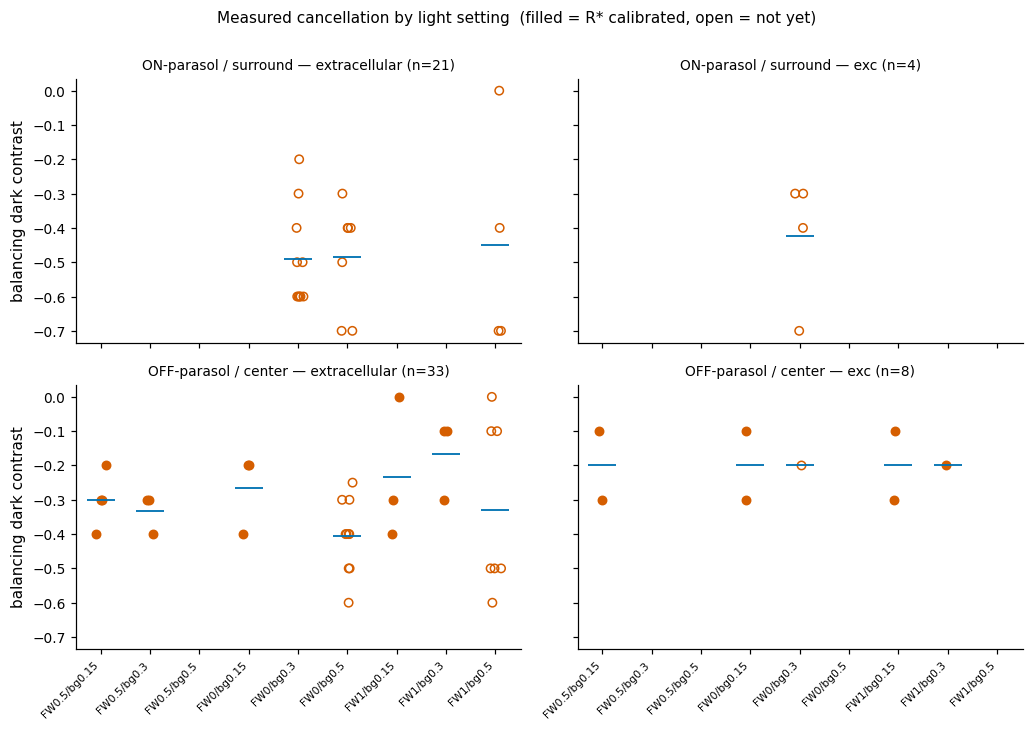

In [10]:
summary = sag.add_condition(sag.load_summary())
print(f'{len(summary)} records | with R*: {int(summary.rstar.notna().sum())}'
      f' | awaiting calibration: {int(summary.rstar.isna().sum())}')

sag.plot_crossing_by_light_setting(summary);

### Against the Weber prediction

The population figure from `populationSpotAnnularGrating.m`: the Weber/Naka-Rushton prediction
`R(I) = I/(I+I0)` drawn continuously across light level with each measured crossing on top, one
panel per condition × recording mode.

This is the figure the calibration was blocking. Every record with a filter-wheel reading now has
an R*, so the panels are populated rather than nearly empty, and the measured crossings span
roughly 1000–23000 R* — about a 20-fold range of light levels, which is what makes the
comparison a real test of the cone model rather than a scatter at one intensity.

The prediction curve still uses `DEFAULTS['cone_i0'] = 2000` R*. That is the MATLAB's value and
it is now the only unmeasured number left in this figure, so it is the obvious thing to fit
rather than assume.

55/80 records have no R* and are not plotted; they need a calibration for: FW0.5/bg0.5, FW0/bg0.3, FW0/bg0.5, FW1/bg0.5


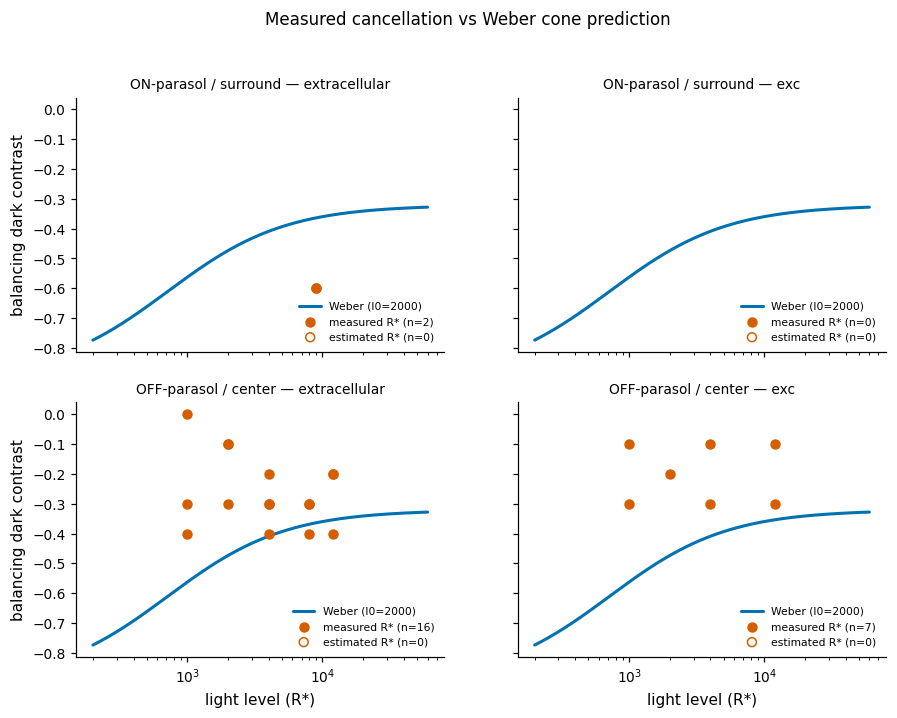

In [11]:
sag.plot_weber_comparison(summary);

In [12]:
# The light level now comes from the rig calibration, so nothing here needs
# filling in. Two ways to restate it if the rigs are ever re-measured:
#
# 1. Change the calibration and re-run sections 1-5 -- the right move, since it
#    is per rig and everything downstream follows:
#
#        sag.RIG_MAX_RSTAR = {'E': 30000.0, 'G': 77000.0}
#
# 2. Override stored records without re-analyzing, for a quick what-if. The
#    crossings never depended on the conversion, so this is safe -- but the
#    keys are (filter wheel, background) with no rig, so only use it on a
#    summary filtered to one rig:
#
#        rig_g = summary[summary.exp_name.str.endswith('_G')]
#        sag.plot_weber_comparison(sag.add_condition(
#            sag.apply_rstar_mapping(rig_g, {(0.0, 0.15): 12000})))

print('R* ceiling at intensity 1.0, per rig and filter-wheel setting')
display(pd.DataFrame(
    [{'rig': rig, **{f'NDF {n:g}': round(sag.max_rstar(rig, n)) for n in (0.0, 0.5, 1.0)}}
     for rig in sag.RIG_MAX_RSTAR]).set_index('rig'))

R* ceiling at intensity 1.0, per rig and filter-wheel setting


,NDF 0,NDF 0.5,NDF 1
rig,,,
E,30000,9487,3000
G,77000,24350,7700


### Population tuning curves, one per light level

The Weber comparison above reduces each recording to a single number, the crossing. This is the
data that number came from: the whole response-vs-dark-bar-contrast curve, averaged across cells,
with the light levels overlaid so the shift between them is on one pair of axes.

**What is averaged.** Each recording contributes `resp_mean - baseline_mean` — its response
relative to its own pre-stimulus baseline, which is the curve whose zero crossing *is* the
balancing contrast. Subtracting per cell is what makes cells poolable at all; a raw rate says as
much about a cell's spontaneous activity as about the stimulus.

**Why normalized by default.** Each cell's curve is then divided by its own peak
`|response - baseline|`. Cells differ enormously in absolute response — the excitatory-current
records here span 1.2 to 538 pA, so a raw mean would be the loudest cell plus noise; firing rates
are milder at 16–92 Hz but still 6-fold. The divisor is a *positive* scalar, so every zero
crossing stays exactly where it was: normalizing changes how much each cell counts, never what
the measurement says. Pass `normalize=False` for recorded units, which only means anything within
one recording mode.

A cell recorded more than once in the same condition and light level is averaged to one curve
first, so it does not count twice. Recordings sampling fewer than three dark contrasts are not
tuning curves and are dropped — that removes the eight single-contrast records in the store.

Light level is an ordered quantity, so the curves use the house sequential ramp (`cividis`, dim
→ bright) rather than categorical colors, and the mapping is built once across every level so a
given R* is the same color in every panel. Shading is SEM across cells; `min_cells=2` hides a
level resting on a single cell.

**Reading the whole-cell panels.** Excitatory current is inward, so those curves sit below zero
and are not sign-flipped to match the spiking panels — the sign is as recorded. They are also
thin (n = 2–4), so the extracellular column is the one to trust.

In [ ]:
sag.plot_population_tuning(summary);

# The numbers behind the curves: one row per (condition, mode, light level,
# dark contrast) with the SEM and the cell count each point rests on.
tuning = sag.population_tuning(summary)
display(tuning.groupby(['condition', 'online_analysis', 'rstar_level'])
               .agg(contrasts=('dark_contrast', 'size'),
                    cells=('n_cells', 'max')).reset_index())

### Example data behind each panel

The recording with the most epochs in each condition × mode, with its own baseline, measured
crossing and the Weber prediction at that recording's light level.

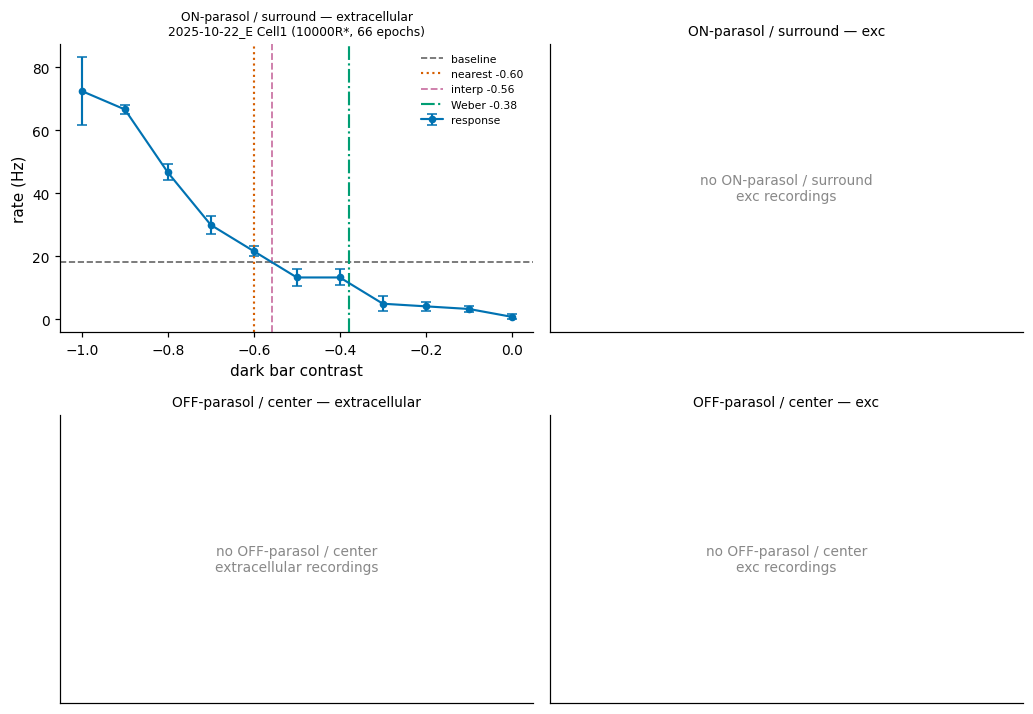

In [13]:
# Falls back to the stored records when the batch above was skipped.
sag.plot_condition_examples(records);

## 7. The model on its own — clean curves for a talk

Section 6 draws the cone model with recordings on top of it, which is what a test of the model
has to look like. This section draws the same model with the data taken off, so the shape can be
explained on a slide before any measurement is shown.

Nothing here reads `records.h5`, the summary, DataJoint or the SSD — the only inputs are `I0` and
the bright-bar contrast, so these cells run in a cold kernel and are safe to re-run while a batch
is going.

### Gain against light level

Everything in this notebook comes out of one equation, the Naka-Rushton cone response

$$R(I) = \frac{I}{I + I_0}$$

and "gain" is its slope. There are two useful versions of that slope and the difference between
them is the whole figure:

- **Incremental gain**, $dR/dI = I_0/(I+I_0)^2$ — response per unit *absolute* change in
  intensity. Plotted relative to its dark-adapted value $1/I_0$, so it starts at 1 and falls.
  This is the panel that says "the cell turns its gain down as the lights come up."
- **Contrast gain**, $I\,dR/dI$ — response per unit *contrast*, which is what a grating
  experiment actually probes, since a bar is specified as a fraction of the mean. Plotted
  relative to its peak.

**Where Weber comes in.** A system obeying Weber's law exactly holds contrast gain *flat*: gain
falls as $1/I$, so a fixed contrast gives a fixed response at every background and the cell
signals contrast rather than intensity. On the left panel that is the dashed slope $-1$ line. The
model tracks it near $I_0$ and then falls away faster, which the right panel shows directly — the
contrast gain peaks at $I = I_0$ and rolls off as $I_0/I$ above it. A static saturation has no
mechanism to keep up, so this model is Weber-like around and below $I_0$ and progressively
sub-Weber above it.

That roll-off is not a detail; it *is* the prediction being tested. It is why the cancelling dark
contrast in the next figure saturates rather than staying at $-c$.

`I0 = 2000` R* (`sag.DEFAULTS['cone_i0']`, the MATLAB's value) is the dotted vertical line and
the one number in the figure nobody measured. This dataset spans 1155–23100 R*, so all but the
dimmest recordings sit above it, on the falling limb — pass `highlight=` to shade that span.

In [ ]:
# Model only -- no data on the axes and nothing read from disk.
sag.plot_weber_gain(i0=sag.DEFAULTS['cone_i0']);

# Variants worth having on hand for a talk:
#
#   one panel only, bigger:
#       sag.plot_weber_gain(kind='contrast', figsize=(5.6, 4.2))
#
#   how much the figure rests on I0, the one unmeasured number:
#       sag.plot_weber_gain(i0=[500, 2000, 8000])
#
#   with the light levels this dataset covers shaded in (context, not an
#   overlay -- it draws no points):
#       sag.plot_weber_gain(highlight=(summary.rstar.min(), summary.rstar.max()))

### The contrast that negates the bright bar

The model drawn on the same axes as the data: dark-bar contrast across, response up, one curve
per light level — the clean counterpart to the population tuning curves above, with no recordings
on it. Bright bar fixed at 0.9, light levels 1000 to 16000 R*, which is the range the protocol
actually spans (1155–23100 R*).

**What the curve is.** The cell sees both bar sets at once, so the predicted response is their
sum through $R(I) = I/(I+I_0)$, written as the two deviations from the mean:

$$\mathrm{net}(c) = \frac{I_b - I_m}{I_b + I_0} + \frac{I_d - I_m}{I_d + I_0},
\qquad I_b = I_m(1+0.9),\quad I_d = I_m(1+c)$$

At $c = 0$ the dark stripes sit at background and only the bright bars deviate, so the response
is entirely bright-bar driven. As the dark bars deepen they pull the other way, and where the two
cancel the curve crosses zero — that zero is exactly what `cone_predict_dark_contrast` solves
for, so the ▾ markers are the same numbers §6 plots against light level.

**Read the crossings.** −0.56, −0.47, −0.41, −0.37, −0.35 as the background goes 1000 → 16000
R*. They march toward zero, because saturation compresses the bright bar more than the dark one
and less dark contrast is needed to balance it. Note how unevenly they are spaced: the first
doubling of light moves the crossing by 0.09, the last by 0.02. Sixteen-fold more light buys
0.22 of contrast, and most of it is spent near $I_0$ — which is why the measurement wants light
levels *around* 2000 R*, not a wide sweep at the bright end.

**Sign and scale.** `net` is the cone signal, which goes negative as the dark bars deepen; both
conditions here (ON-parasol surround, OFF-parasol center) are ones where a dark bar *drives* the
cell, so the plotted curve is $-\mathrm{net}$ — positive at the deepest dark bar, the orientation
the measured curves come out in. Each curve is then divided by its own value at $c = -1$, the one
point every recording of this protocol has in common, so all five are pinned at +1 there and the
crossings can be read against each other. Both operations are sign or positive-scalar changes;
neither moves a crossing. `normalize=False` shows the raw model amplitudes, where a black bar
against a bright background is an enormous signal and the dim curves vanish.

,cancelling dark contrast
R*,
1000,-0.562
2000,-0.474
4000,-0.409
8000,-0.369
16000,-0.346


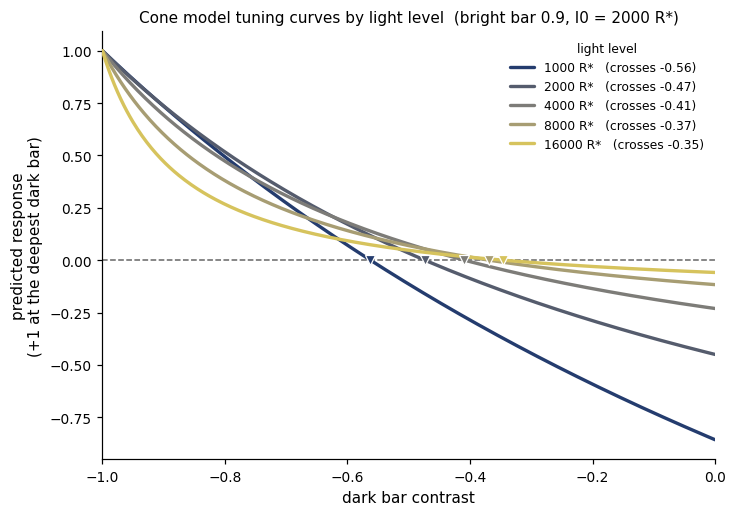

In [13]:
# Model only -- the same axes as the population tuning figure above, with no
# recordings on them. The zero crossings (marked) are cone_predict_dark_contrast.
sag.plot_model_tuning(light_levels=(1000, 2000, 4000, 8000, 16000),
                      bright_contrast=0.9);

# The numbers behind the markers.
display(pd.DataFrame([
    {'R*': lvl, 'cancelling dark contrast':
        round(sag.cone_predict_dark_contrast(lvl, 0.9), 3)}
    for lvl in (1000, 2000, 4000, 8000, 16000)]).set_index('R*'))

# Variants:
#   raw model amplitude instead of pinning every curve at the deepest dark bar
#   -- a black bar against a bright mean is a huge signal, so this is dominated
#   by the brightest level and is the reason the default normalizes:
#       sag.plot_model_tuning(normalize=False)
#
#   the same prediction reduced to its crossing and plotted against light level,
#   which is the curve section 6 draws the recordings over:
#       sag.plot_weber_prediction(bright_contrast=0.9)

## 8. Come back later

`load_summary()` reads only the scalar index, so population work starts in a cold kernel with
no DataJoint and no SSD access; `load_records()` pulls full arrays for chosen keys.

In [13]:
summary = sag.add_condition(sag.load_summary())
sc.scroll_table(summary[['exp_name', 'cell_label', 'cell_type_short', 'online_analysis',
                         'grating_site', 'light_level', 'rstar', 'crossing_nearest',
                         'cone_pred_dark', 'n_epochs']], height=320)

full = sag.load_records([summary['key'].iloc[0]])[summary['key'].iloc[0]]
print('arrays in a record:', [k for k, v in full.items() if getattr(v, 'ndim', 0) > 0])
print('dark contrasts:', np.round(full['dark_contrasts'], 2))
print('tuning curve  :', np.round(full['resp_mean'], 2))

exp_name,cell_label,cell_type_short,online_analysis,grating_site,light_level,rstar,crossing_nearest,cone_pred_dark,n_epochs
2025-10-22_E,Cell3,OFF-parasol,exc,surround,FW0/bg0.3 (?R*),,-1.0,,33
2025-10-22_E,Cell3,OFF-parasol,extracellular,surround,FW0/bg0.3 (?R*),,-1.0,,66
2025-11-06_E,Cell4,OFF-parasol,exc,surround,FW0/bg0.3 (?R*),,-0.6,,99
2026-01-02_E,Cell6,OFF-parasol,exc,surround,FW0/bg0.3 (?R*),,-0.9,,15
2026-02-26_E,Cell1,OFF-parasol,extracellular,center,FW0/bg0.5 (?R*),,-0.5,-0.3315789473684211,47
2026-02-26_E,Cell5,OFF-parasol,extracellular,center,FW0/bg0.5 (?R*),,-0.6,-0.3315789473684211,83
2026-04-03_E,Cell4,OFF-parasol,extracellular,center,FW0/bg0.5 (?R*),,-0.4,-0.3315789473684211,33
2026-04-04_E,Cell1,OFF-parasol,extracellular,center,FW0/bg0.5 (?R*),,-0.25,-0.1693548387096775,30
2026-04-04_E,Cell1,OFF-parasol,extracellular,center,FW1/bg0.5 (?R*),,-0.5,-0.3076923076923077,20
2026-04-14_E,Cell1,OFF-parasol,extracellular,center,FW0/bg0.5 (?R*),,-0.3,-0.3315789473684211,77


arrays in a record: ['bar_widths', 'dark_contrasts', 'resp_mean', 'resp_n', 'resp_sem', 'trace_time_ms', 'traces']
dark contrasts: [-1.  -0.9 -0.8 -0.7 -0.6 -0.5 -0.4 -0.3 -0.2 -0.1  0. ]
tuning curve  : [-1.77 -1.95 -1.94 -2.6  -2.86 -2.98 -2.89 -3.09 -3.07 -2.67 -3.88]


## Inspect one cell

Everything above runs across the whole dataset. This section goes the other way: name a single
cell and see every recording of it, split by condition.

A cell is identified by `'<experiment>/<cell label>'`, e.g. `'2026-06-04_G/Cell4'`. `list_cells` shows the
available ids together with the conditions each cell was recorded in — recording mode, site,
light setting, and whatever else varies for this protocol — so you can pick one. A bare cell
label also works when it is unambiguous.

In [14]:
sag.list_cells(selected)

38 cells, 76 recording conditions in total


cell_id,cell_type,conditions,epochs,onlineAnalysis,grating_site,aperture,annulus_inner,annulus_outer,light_setting,filter_wheel_ndf,backgroundIntensity
2025-10-22_E/Cell3,OFF-parasol,2,99,"exc, extracellular",surround,350.0,450.0,1200.0,FW0/bg0.3,0.0,0.3
2025-11-06_E/Cell4,,1,99,exc,surround,250.0,350.0,1200.0,FW0/bg0.3,0.0,0.3
2026-01-02_E/Cell6,,1,15,exc,surround,300.0,400.0,1200.0,FW0/bg0.3,0.0,0.3
2026-02-26_E/Cell1,,1,47,extracellular,center,0.0,0.0,300.0,FW0/bg0.5,0.0,0.5
2026-02-26_E/Cell5,,1,83,extracellular,center,0.0,0.0,300.0,FW0/bg0.5,0.0,0.5
2026-04-03_E/Cell4,,1,33,extracellular,center,0.0,0.0,200.0,FW0/bg0.5,0.0,0.5
2026-04-04_E/Cell1,,2,50,extracellular,center,0.0,0.0,500.0,"FW0/bg0.5, FW1/bg0.5","0.0, 1.0",0.5
2026-04-14_E/Cell1,,3,220,extracellular,"center, surround","0.0, 200.0","0.0, 300.0","1200.0, 300.0","FW0/bg0.5, FW1/bg0.5","0.0, 1.0",0.5
2026-04-14_E/Cell3,,2,220,extracellular,center,0.0,0.0,400.0,"FW0/bg0.5, FW1/bg0.5","0.0, 1.0",0.5
2026-04-23_E/Cell1,,2,99,extracellular,center,0.0,0.0,500.0,"FW0/bg0.5, FW1/bg0.5","0.0, 1.0",0.5


,cell_id,cell_type,conditions,epochs,onlineAnalysis,grating_site,aperture,annulus_inner,annulus_outer,light_setting,filter_wheel_ndf,backgroundIntensity
0,2025-10-22_E/Cell3,OFF-parasol,2,99,"exc, extracellular",surround,350.0,450.0,1200.0,FW0/bg0.3,0.0,0.3
1,2025-11-06_E/Cell4,OFF-parasol,1,99,exc,surround,250.0,350.0,1200.0,FW0/bg0.3,0.0,0.3
2,2026-01-02_E/Cell6,OFF-parasol,1,15,exc,surround,300.0,400.0,1200.0,FW0/bg0.3,0.0,0.3
3,2026-02-26_E/Cell1,OFF-parasol,1,47,extracellular,center,0.0,0.0,300.0,FW0/bg0.5,0.0,0.5
4,2026-02-26_E/Cell5,OFF-parasol,1,83,extracellular,center,0.0,0.0,300.0,FW0/bg0.5,0.0,0.5
5,2026-04-03_E/Cell4,OFF-parasol,1,33,extracellular,center,0.0,0.0,200.0,FW0/bg0.5,0.0,0.5
6,2026-04-04_E/Cell1,OFF-parasol,2,50,extracellular,center,0.0,0.0,500.0,"FW0/bg0.5, FW1/bg0.5","0.0, 1.0",0.5
7,2026-04-14_E/Cell1,OFF-parasol,3,220,extracellular,"center, surround","0.0, 200.0","0.0, 300.0","1200.0, 300.0","FW0/bg0.5, FW1/bg0.5","0.0, 1.0",0.5
8,2026-04-14_E/Cell3,OFF-parasol,2,220,extracellular,center,0.0,0.0,400.0,"FW0/bg0.5, FW1/bg0.5","0.0, 1.0",0.5
9,2026-04-23_E/Cell1,OFF-parasol,2,99,extracellular,center,0.0,0.0,500.0,"FW0/bg0.5, FW1/bg0.5","0.0, 1.0",0.5


2026-06-04_G/Cell4  |  OFF-parasol  |  10 recording condition(s), 11 blocks, 556 epochs
   [0] onlineAnalysis=extracellular | light_setting=FW1/bg0.3 | filter_wheel_ndf=1.0 | backgroundIntensity=0.3  (2 blocks, 98 epochs)
   [1] onlineAnalysis=extracellular | light_setting=FW0.5/bg0.15 | filter_wheel_ndf=0.5 | backgroundIntensity=0.15  (1 blocks, 66 epochs)
   [2] onlineAnalysis=extracellular | light_setting=FW1/bg0.15 | filter_wheel_ndf=1.0 | backgroundIntensity=0.15  (1 blocks, 66 epochs)
   [3] onlineAnalysis=extracellular | light_setting=FW0/bg0.15 | filter_wheel_ndf=0.0 | backgroundIntensity=0.15  (1 blocks, 66 epochs)
   [4] onlineAnalysis=exc | light_setting=FW0/bg0.15 | filter_wheel_ndf=0.0 | backgroundIntensity=0.15  (1 blocks, 66 epochs)
   [5] onlineAnalysis=extracellular | light_setting=FW0.5/bg0.3 | filter_wheel_ndf=0.5 | backgroundIntensity=0.3  (1 blocks, 61 epochs)
   [6] onlineAnalysis=exc | light_setting=FW1/bg0.3 | filter_wheel_ndf=1.0 | backgroundIntensity=0.3  (1 b

onlineAnalysis,grating_site,aperture,annulus_inner,annulus_outer,light_setting,filter_wheel_ndf,backgroundIntensity,blocks,epochs,block_ids
extracellular,center,0.0,0.0,300.0,FW1/bg0.3,1.0,0.3,2,98,"35054, 35056"
extracellular,center,0.0,0.0,300.0,FW0.5/bg0.15,0.5,0.15,1,66,35051
extracellular,center,0.0,0.0,300.0,FW1/bg0.15,1.0,0.15,1,66,35053
extracellular,center,0.0,0.0,300.0,FW0/bg0.15,0.0,0.15,1,66,35052
exc,center,0.0,0.0,300.0,FW0/bg0.15,0.0,0.15,1,66,35065
extracellular,center,0.0,0.0,300.0,FW0.5/bg0.3,0.5,0.3,1,61,35055
exc,center,0.0,0.0,300.0,FW1/bg0.3,1.0,0.3,1,46,35063
exc,center,0.0,0.0,300.0,FW1/bg0.15,1.0,0.15,1,36,35062
exc,center,0.0,0.0,300.0,FW0.5/bg0.15,0.5,0.15,1,32,35061
exc,center,0.0,0.0,300.0,FW0/bg0.3,0.0,0.3,1,19,35064


If this is for an LED stimulus, be sure to set b_LED=True!

Error occurred while getting actual onset/offset times: unsupported operand type(s) for *: 'float' and 'NoneType'
It could be that frame_times_ms do not have the correct number of frames due to some error in frame detection.
Check the frame monitor sample rate! On MEA Rigs, prefer 1k, errors likely with 10k.


Max trial length in data points: 10000 = 1 s
Trial 1: Found 2342 peaks


Trial 1: Found 20 spikes
Trial 2: Found 2349 peaks
Trial 2: Found 17 spikes
Trial 3: Found 2359 peaks
Trial 3: Found 14 spikes
Trial 4: Found 2363 peaks


...

2026-06-04_G | RGC\OFF-parasol | Cell4 | exc | grating center | FW=1.0 bg=0.15 (1000R*) | 36 epochs
  dark contrasts : [-1.  -0.9 -0.8 -0.7 -0.6 -0.5 -0.4 -0.3 -0.2 -0.1  0. ]
  response       : [263.693 209.983 132.475 155.196 117.262  75.268  53.381   7.14  -10.017
  -3.385 -25.782]
  baseline=0.000 | crossing nearest=-0.100 interp=-0.258 | cone pred=-0.562


If this is for an LED stimulus, be sure to set b_LED=True!

Error occurred while getting actual onset/offset times: unsupported operand type(s) for *: 'float' and 'NoneType'
It could be that frame_times_ms do not have the correct number of frames due to some error in frame detection.
Check the frame monitor sample rate! On MEA Rigs, prefer 1k, errors likely with 10k.


2026-06-04_G | RGC\OFF-parasol | Cell4 | exc | grating center | FW=0.5 bg=0.15 (4000R*) | 32 epochs
  dark contrasts : [-1.  -0.9 -0.8 -0.7 -0.6 -0.5 -0.4 -0.3 -0.2 -0.1  0. ]
  response       : [339.856 285.794 225.04  212.064 198.933 150.342  92.162  53.436  25.87
   1.294 -16.512]
  baseline=-0.000 | crossing nearest=-0.100 interp=-0.093 | cone pred=-0.409


If this is for an LED stimulus, be sure to set b_LED=True!

Error occurred while getting actual onset/offset times: unsupported operand type(s) for *: 'float' and 'NoneType'
It could be that frame_times_ms do not have the correct number of frames due to some error in frame detection.
Check the frame monitor sample rate! On MEA Rigs, prefer 1k, errors likely with 10k.


2026-06-04_G | RGC\OFF-parasol | Cell4 | exc | grating center | FW=0.0 bg=0.30 (FW0/bg0.3 (?R*)) | 19 epochs
  dark contrasts : [-0.9 -0.8 -0.7 -0.6 -0.5 -0.4 -0.3 -0.2 -0.1  0. ]
  response       : [538.162 368.38  303.676 203.43  135.31   89.356  15.882  -7.057 -28.104
 -57.117]
  baseline=0.000 | crossing nearest=-0.200 interp=-0.231 | cone pred=nan
analyzed 10/10 conditions for 2026-06-04_G/Cell4


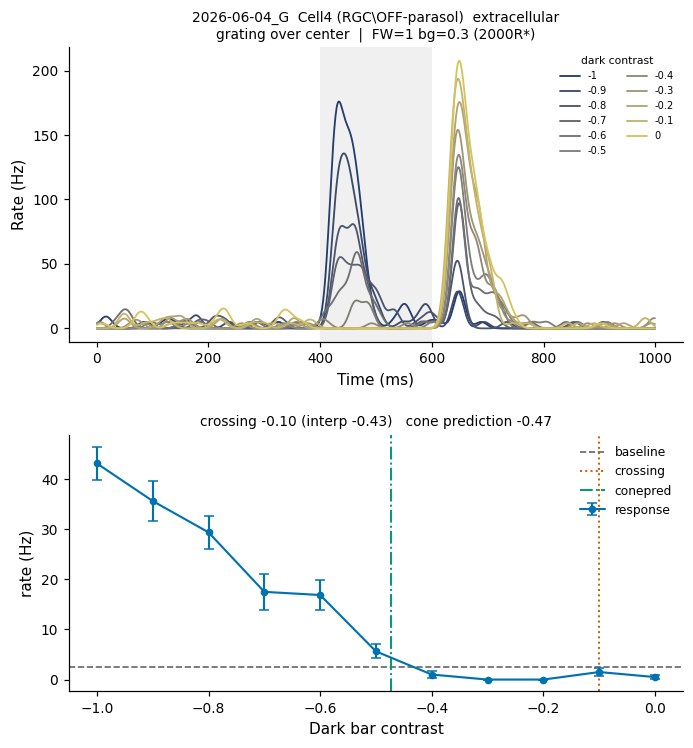

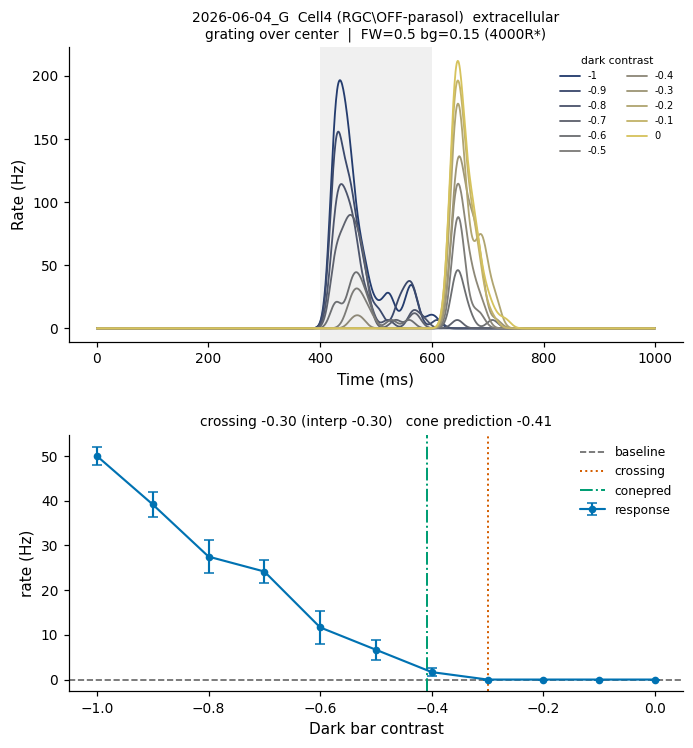

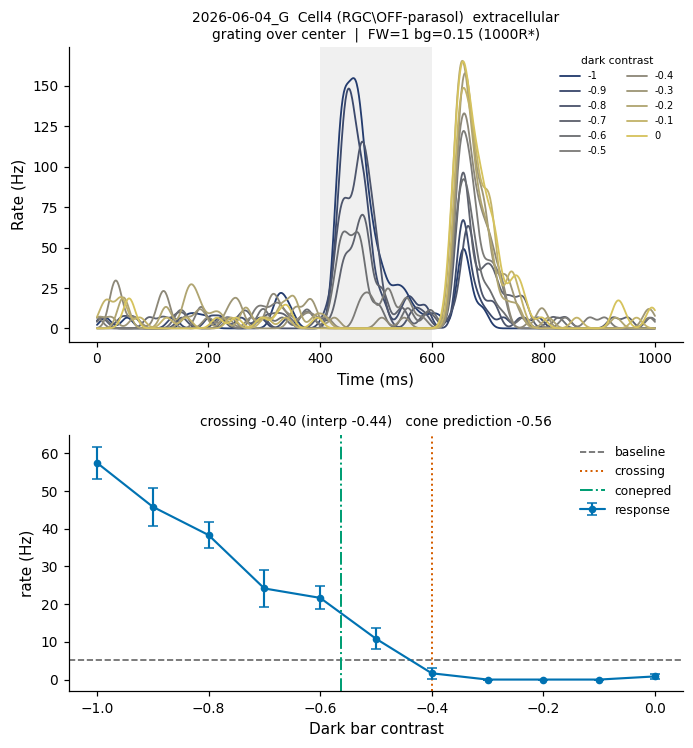

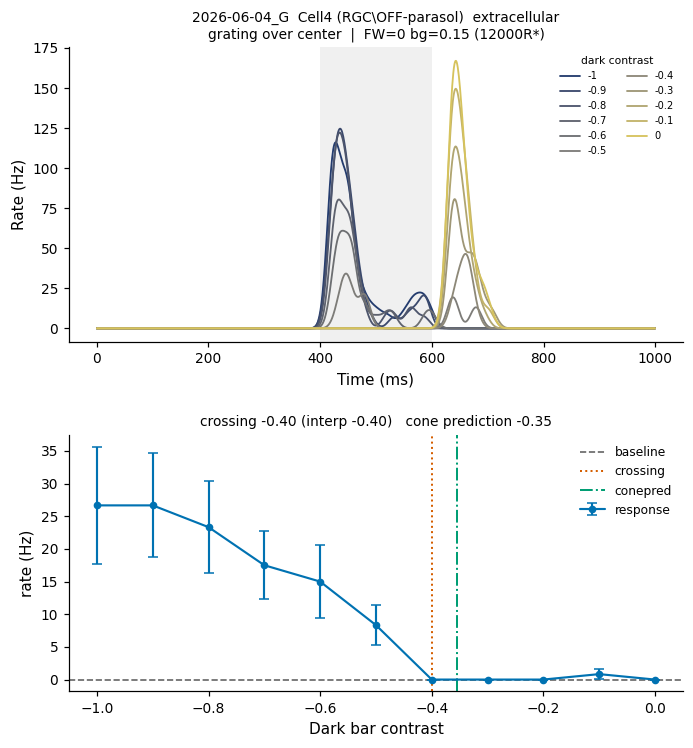

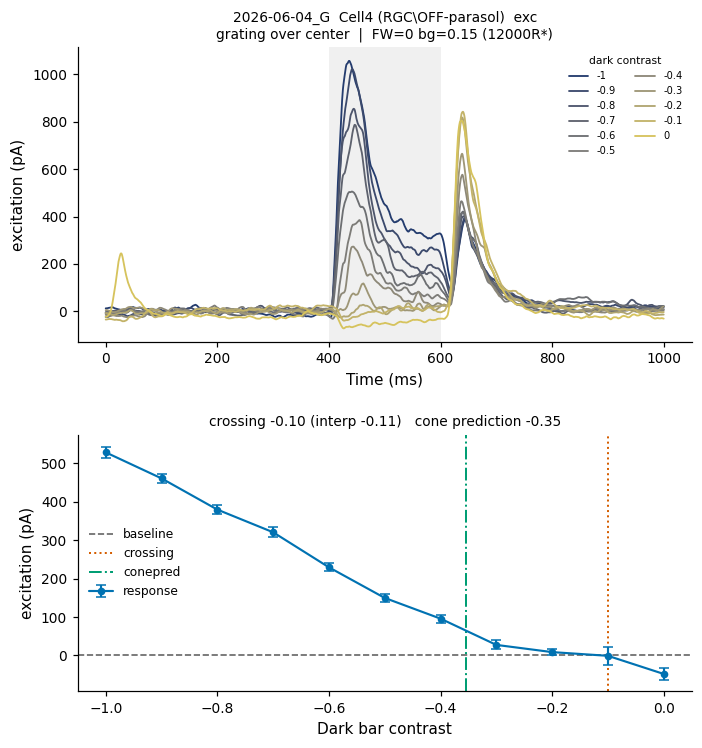

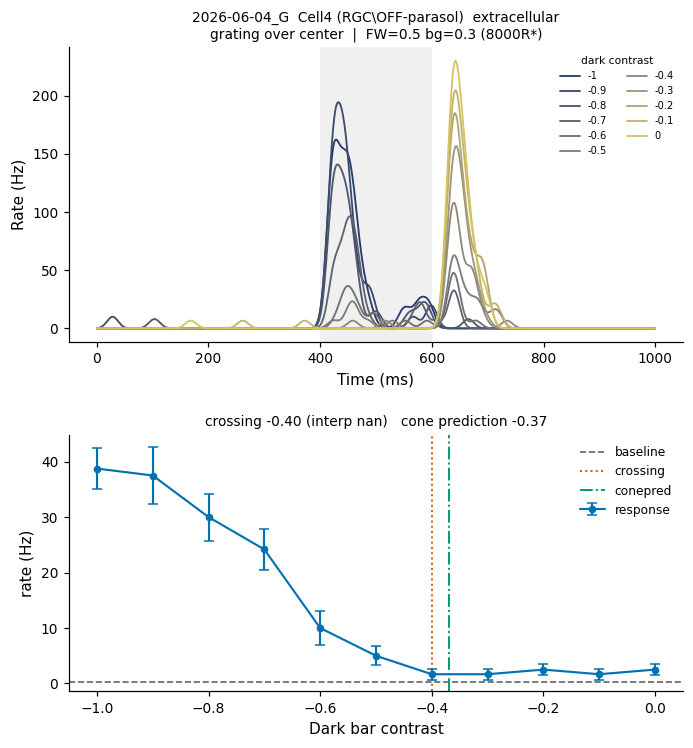

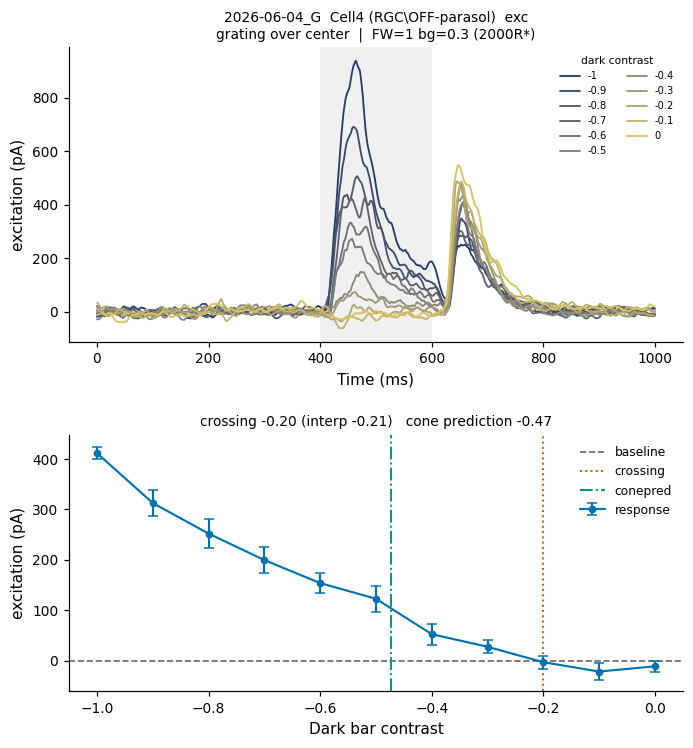

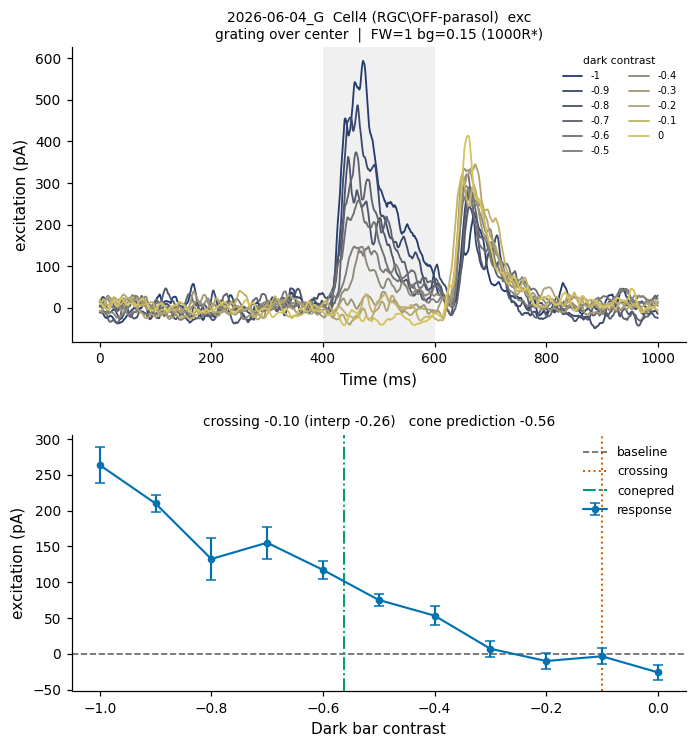

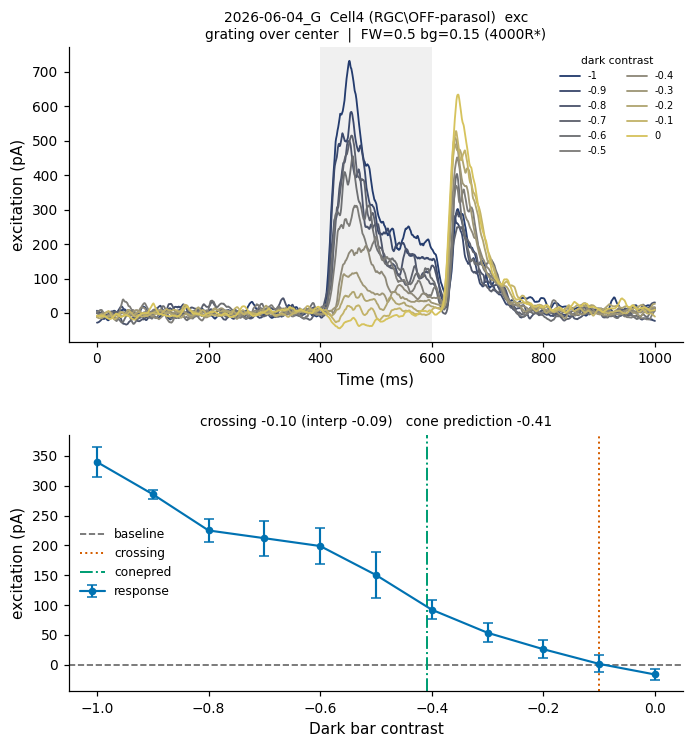

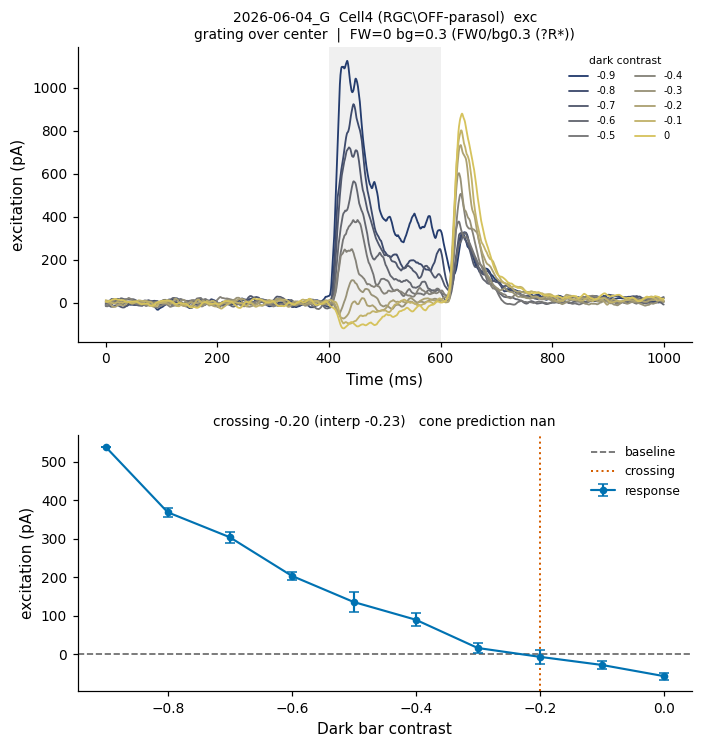

In [15]:
# Change CELL to inspect a different one. Each condition is analyzed and
# plotted in turn, and the records are returned for further poking.
CELL = '2026-06-04_G/Cell4'

cell_records = sag.inspect_cell(CELL, selected)